# Time Series Fundamentals

## Learning Objectives

- Understand what makes time series data fundamentally different from cross-sectional data.
- Define and test for **stationarity** — the key assumption underlying most time series models.
- Compute and interpret **autocorrelation** and **partial autocorrelation** functions.
- Fit and diagnose **AR**, **MA**, and **ARIMA** models using statsmodels.
- Produce and evaluate **forecasts** with confidence intervals.
- Recognise the connections between time series methods and the regression/Bayesian tools from earlier modules.

## Prerequisites

- Module 06 (Linear Models — regression, residual analysis)
- Module 04.03 (Maximum Likelihood Estimation)
- Familiarity with NumPy, matplotlib, pandas

In [28]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()

rng = np.random.default_rng(42)


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files.")


cfg = Cfg()

In [29]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

---

## 1. What Makes Time Series Special?

A **time series** is an ordered sequence of observations indexed by time:

$$\{Y_t\}_{t=1}^{T} = Y_1, Y_2, \ldots, Y_T$$

This sounds deceptively simple — after all, Module 06's regression models also handle ordered data. But time series data has a fundamental property that changes everything: **temporal dependence**. Nearby observations are correlated with each other because they share common underlying causes, trends, and momentum.

In cross-sectional data (e.g., heights of 200 random people), observations are independent — knowing person 47's height tells you nothing about person 48's. In time series data (e.g., daily temperatures), knowing today's temperature tells you a lot about tomorrow's.

### 1.1 Three components of a time series

Most time series can be decomposed (conceptually or mathematically) into three components:

$$Y_t = T_t + S_t + R_t$$

where:
- $T_t$ is the **trend** — the long-run direction (upward, downward, or flat)
- $S_t$ is the **seasonality** — regular periodic patterns (daily, weekly, yearly)
- $R_t$ is the **residual** (noise) — the irregular fluctuations left over

The figure below shows a synthetic time series with all three components visible, then decomposes it into its parts.

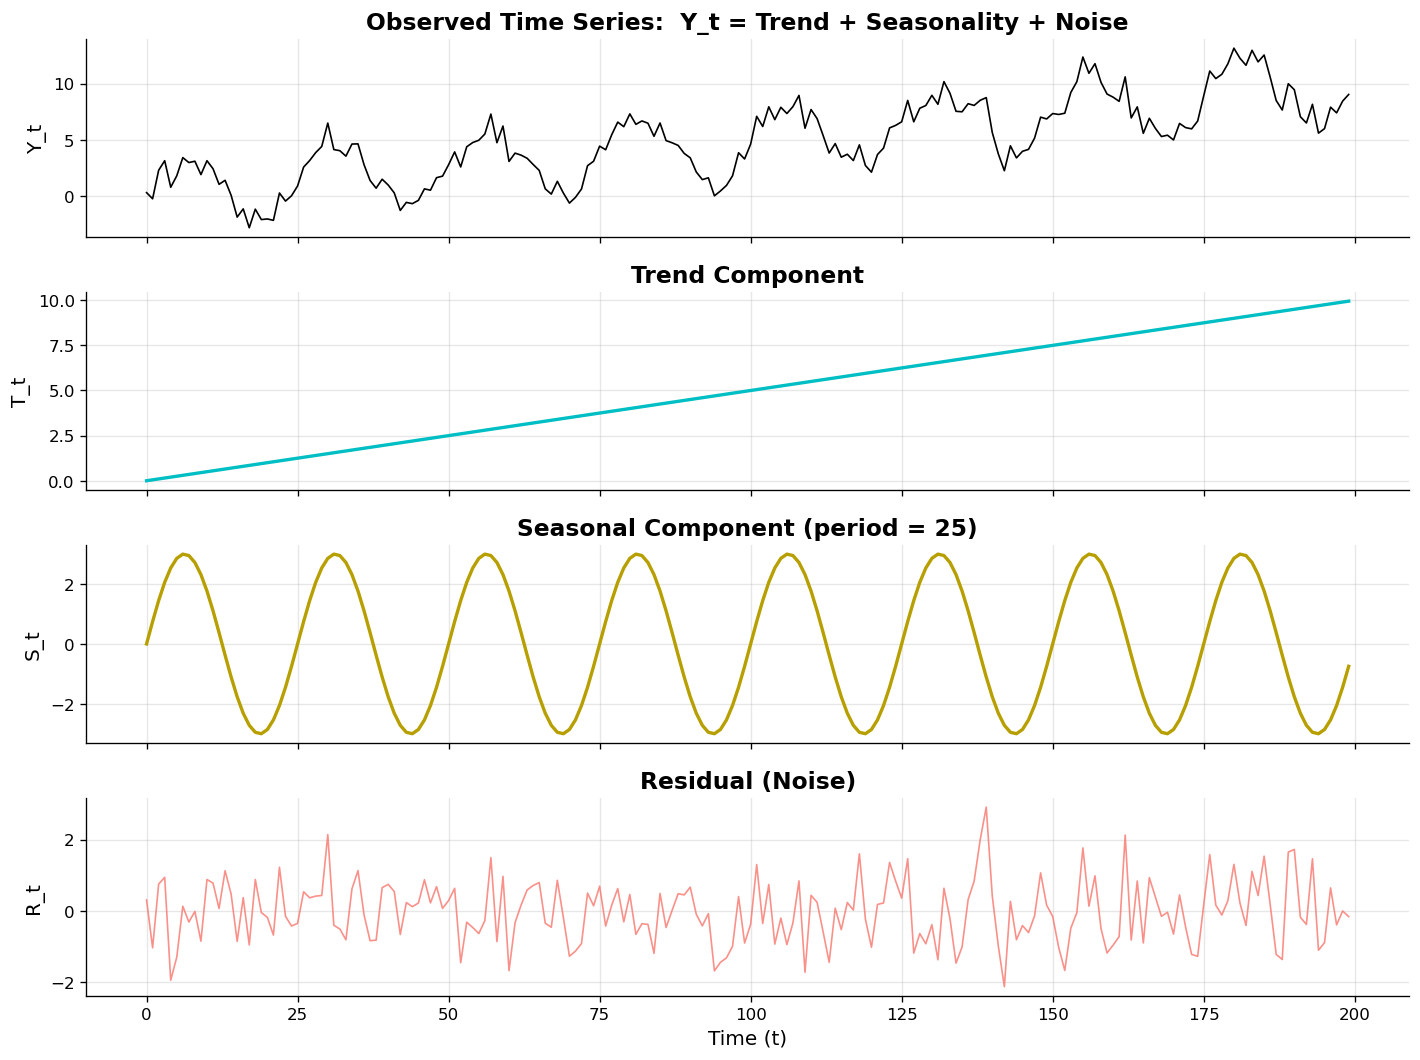

In [3]:
# Generate a synthetic time series with trend, seasonality, and noise
T = 200
t = np.arange(T)

trend = 0.05 * t  # linear upward trend
seasonality = 3 * np.sin(2 * np.pi * t / 25)  # period = 25
noise = rng.normal(0, 1, T)  # random noise
y = trend + seasonality + noise

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, y, color="black", lw=1)
axes[0].set_title(
    "Observed Time Series:  Y_t = Trend + Seasonality + Noise", fontweight="bold"
)
axes[0].set_ylabel("Y_t")

axes[1].plot(t, trend, color=str(C.CYAN), lw=2)
axes[1].set_title("Trend Component", fontweight="bold")
axes[1].set_ylabel("T_t")

axes[2].plot(t, seasonality, color=str(C.GOLD), lw=2)
axes[2].set_title("Seasonal Component (period = 25)", fontweight="bold")
axes[2].set_ylabel("S_t")

axes[3].plot(t, noise, color=str(C.SALMON), lw=1, alpha=0.8)
axes[3].set_title("Residual (Noise)", fontweight="bold")
axes[3].set_ylabel("R_t")
axes[3].set_xlabel("Time (t)")

plt.tight_layout()
plt.show()

The fundamental assumption behind all time series modelling is that **the past contains information about the future**. If the residuals were all that existed (pure noise), there would be nothing to model or forecast. It is the trend and seasonal structure — plus any additional serial correlation in the residuals — that makes time series analysis productive.

---

## 2. Stationarity

Most time series models (AR, MA, ARIMA) assume a property called **stationarity**. Intuitively, a stationary process looks the same no matter when you observe it — its statistical properties don't drift over time.

### 2.1 Formal definitions

**Strict stationarity.** A time series $\{Y_t\}$ is strictly stationary if the joint distribution of $(Y_{t_1}, Y_{t_2}, \ldots, Y_{t_k})$ is the same as $(Y_{t_1+h}, Y_{t_2+h}, \ldots, Y_{t_k+h})$ for all choices of times and all shifts $h$.

This is a very strong condition. In practice, we use a weaker version:

**Weak (covariance) stationarity.** A time series is weakly stationary if:

1. **Constant mean:** $E[Y_t] = \mu$ for all $t$
2. **Constant variance:** $\text{Var}(Y_t) = \sigma^2$ for all $t$
3. **Autocovariance depends only on lag:** $\text{Cov}(Y_t, Y_{t+h}) = \gamma(h)$ for all $t$

Condition 3 is the crucial one: the correlation between two observations depends only on how far apart they are in time ($h$), not on when they occur ($t$).

### 2.2 Why stationarity matters

If a process is non-stationary, its mean or variance changes over time. This means:
- The relationship between $Y_t$ and $Y_{t-1}$ changes depending on *when* you look
- Parameter estimates from one part of the series don't apply to another part
- Forecasts are unreliable because the model was fitted to statistics that no longer hold

**The strategy:** Transform non-stationary data into stationary data (typically by differencing), model the stationary residuals, then invert the transformation to produce forecasts.

### 2.3 Stationary vs non-stationary: a visual comparison

The figure below shows two processes side by side:
- **Left:** a stationary AR(1) process — it fluctuates around a constant mean
- **Right:** a random walk $Y_t = Y_{t-1} + \varepsilon_t$ — it wanders without returning to a mean

We also plot rolling mean and standard deviation to highlight the difference.

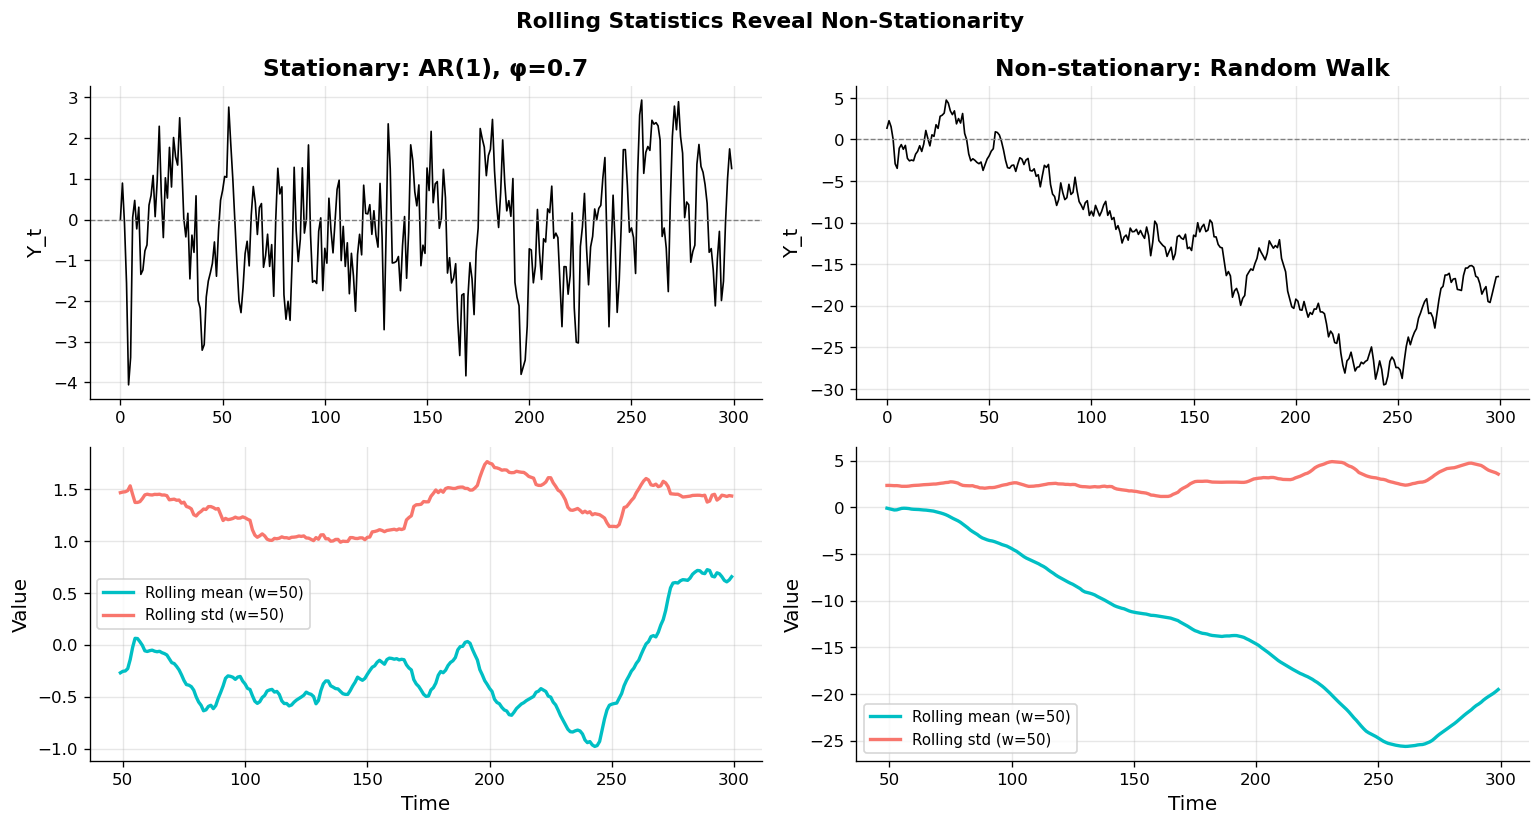

In [ ]:
# Compare stationary vs non-stationary processes
n = 300
eps = rng.normal(0, 1, n)

# Stationary: AR(1) with phi = 0.7
ar1 = np.zeros(n)
for t in range(1, n):
    ar1[t] = 0.7 * ar1[t - 1] + eps[t]

# Non-stationary: random walk
rw = np.cumsum(eps)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

window = 50
for col, (series, name) in enumerate(
    [(ar1, "Stationary: AR(1), φ=0.7"), (rw, "Non-stationary: Random Walk")]
):
    ax_ts, ax_stats = axes[0, col], axes[1, col]

    ax_ts.plot(series, lw=1, color="black")
    ax_ts.axhline(0, color="gray", ls="--", lw=0.8)
    ax_ts.set_title(name, fontweight="bold")
    ax_ts.set_ylabel("Y_t")

    roll_mean = pd.Series(series).rolling(window).mean()
    roll_std = pd.Series(series).rolling(window).std()
    ax_stats.plot(
        roll_mean, label=f"Rolling mean (w={window})", color=str(C.CYAN), lw=2
    )
    ax_stats.plot(
        roll_std, label=f"Rolling std (w={window})", color=str(C.SALMON), lw=2
    )
    ax_stats.legend(fontsize=9)
    ax_stats.set_xlabel("Time")
    ax_stats.set_ylabel("Value")

fig.suptitle(
    "Rolling Statistics Reveal Non-Stationarity", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

The AR(1) process has a rolling mean that stays near zero and a roughly constant rolling standard deviation. The random walk's rolling mean drifts arbitrarily, and its rolling standard deviation grows — classic signs of non-stationarity.

### 2.4 The Augmented Dickey-Fuller test

The **Augmented Dickey-Fuller (ADF)** test is a formal hypothesis test for stationarity:

- $H_0$: The series has a unit root (is non-stationary)
- $H_1$: The series is stationary

A **small p-value** (typically $< 0.05$) rejects $H_0$ and provides evidence for stationarity.

In [6]:
# Augmented Dickey-Fuller test
for series, name in [(ar1, "AR(1)"), (rw, "Random Walk")]:
    result = adfuller(series, autolag="AIC")
    print(f"ADF test for {name}:")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.6f}")
    print(
        f"  Conclusion:     {'Stationary ✓' if result[1] < 0.05 else 'Non-stationary ✗'}"
    )
    print()

ADF test for AR(1):
  Test statistic: -6.1119
  p-value:        0.000000
  Conclusion:     Stationary ✓

ADF test for Random Walk:
  Test statistic: -1.5431
  p-value:        0.512096
  Conclusion:     Non-stationary ✗



### 2.5 Differencing: making non-stationary data stationary

The most common transformation is **differencing**: replacing $Y_t$ with

$$\Delta Y_t = Y_t - Y_{t-1}$$

For a random walk $Y_t = Y_{t-1} + \varepsilon_t$, differencing gives $\Delta Y_t = \varepsilon_t$ — pure white noise, which is stationary. Sometimes we need to difference twice ($d = 2$) if the trend is quadratic, but $d = 1$ handles most cases.

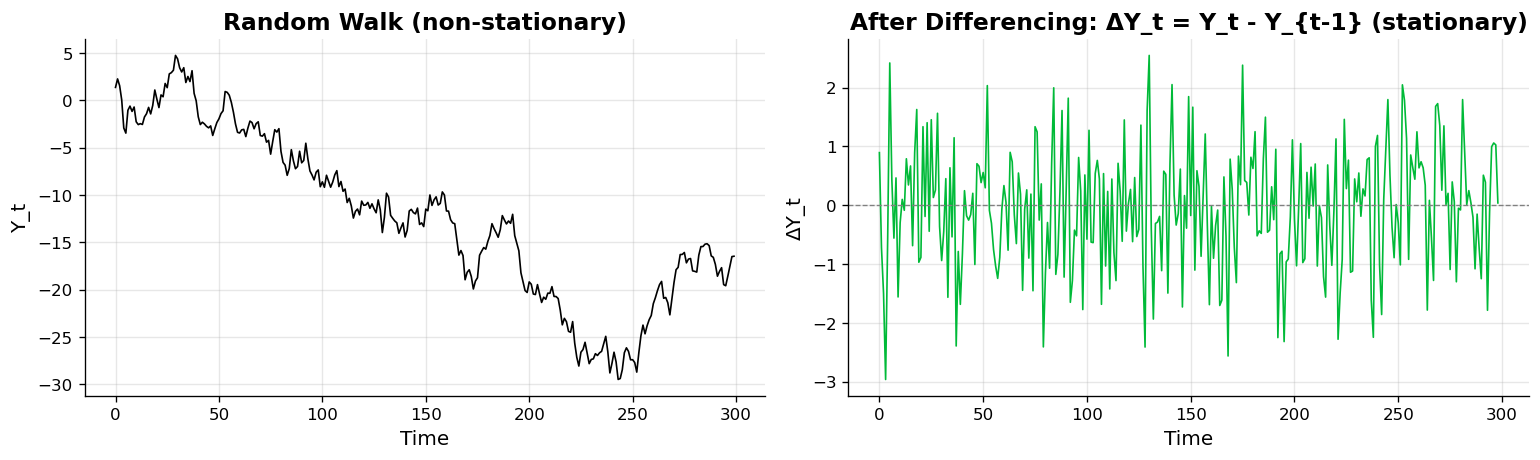

ADF test on differenced series: p-value = 5.385674e-25 → Stationary ✓


In [9]:
# Differencing the random walk
rw_diff = np.diff(rw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(rw, lw=1, color="black")
axes[0].set_title("Random Walk (non-stationary)", fontweight="bold")
axes[0].set_ylabel("Y_t")

axes[1].plot(rw_diff, lw=1, color=str(C.EMERALD))
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_title(
    "After Differencing: ΔY_t = Y_t - Y_{t-1} (stationary)", fontweight="bold"
)
axes[1].set_ylabel("ΔY_t")

for ax in axes:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

# Verify with ADF test
result = adfuller(rw_diff, autolag="AIC")
print(f"ADF test on differenced series: p-value = {result[1]:.6e} → Stationary ✓")

---

## 3. Autocorrelation

Now that we know what stationarity is, we can define the tools that describe the **memory structure** of a stationary time series.

### 3.1 The autocovariance and autocorrelation functions

For a weakly stationary series with mean $\mu$ and variance $\sigma^2$:

**Autocovariance function (ACVF):**
$$\gamma(h) = \text{Cov}(Y_t, Y_{t+h}) = E[(Y_t - \mu)(Y_{t+h} - \mu)]$$

**Autocorrelation function (ACF):**
$$\rho(h) = \frac{\gamma(h)}{\gamma(0)} = \frac{\text{Cov}(Y_t, Y_{t+h})}{\text{Var}(Y_t)}$$

The ACF is just the normalised version of the ACVF, with $\rho(0) = 1$ always.

### 3.2 Partial autocorrelation function (PACF)

The ACF at lag $h$ measures the *total* correlation between $Y_t$ and $Y_{t+h}$, including indirect effects through intermediate values $Y_{t+1}, \ldots, Y_{t+h-1}$.

The **PACF** at lag $h$ measures the *direct* correlation between $Y_t$ and $Y_{t+h}$, after removing the linear effects of the intermediate values. Formally, it is the coefficient $\phi_{hh}$ in the regression:

$$Y_{t+h} = \phi_{h1} Y_{t+h-1} + \phi_{h2} Y_{t+h-2} + \cdots + \phi_{hh} Y_t + \varepsilon_t$$

**Intuition:**
- **ACF** tells you "how far does memory reach?" — it may decay slowly because of indirect chains of correlation.
- **PACF** tells you "what is the *direct* effect at each lag?" — it isolates the contribution of each specific lag.

### 3.3 ACF and PACF in practice

Before we quantify autocorrelation, let's first *see* it. The plot below shows 500 observations from an AR(2) process with $\phi_1 = 0.5$ and $\phi_2 = -0.3$. Watch how the series doesn't jump erratically like white noise — nearby values are pulled toward each other (positive $\phi_1$), while the negative $\phi_2$ introduces a subtle oscillatory quality. The zoomed-in window on the right makes this local dependence structure easier to spot: consecutive points tend to move together, and the series "remembers" its recent past. The question is — how far does this memory reach, and how strong is it? That's exactly what the ACF will tell us.


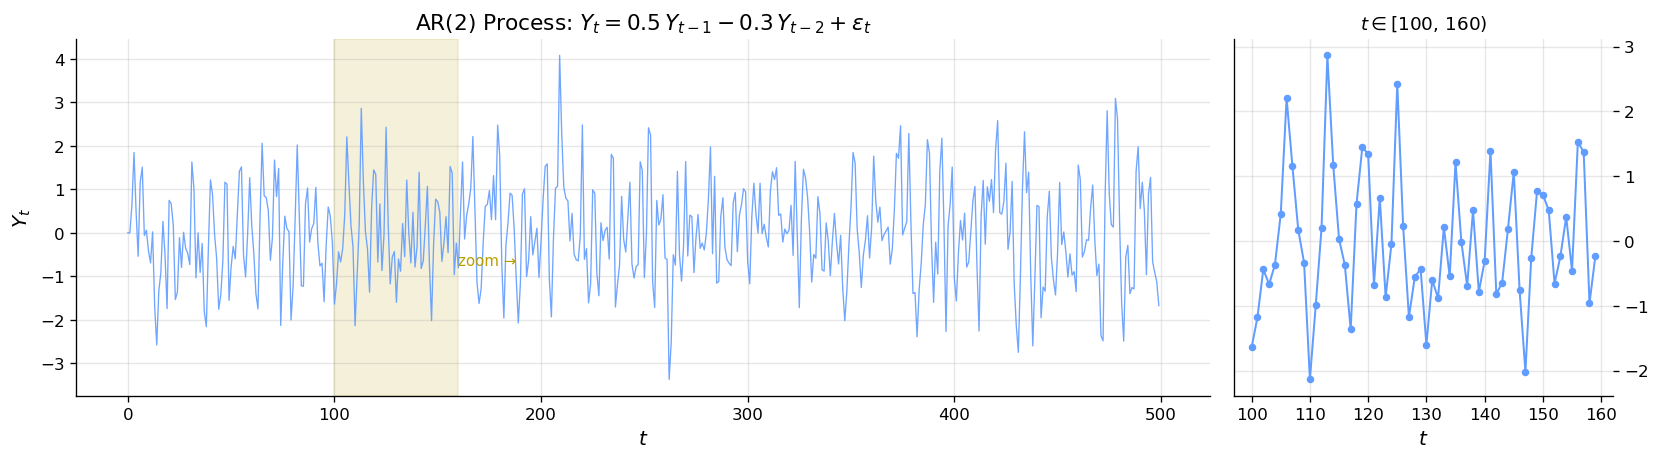

In [ ]:
# Visualise the AR(2) series
n = 500
np.random.seed(42)
eps = np.random.normal(0, 1, n)
y_ar2 = np.zeros(n)
for t in range(2, n):
    y_ar2[t] = 0.5 * y_ar2[t - 1] - 0.3 * y_ar2[t - 2] + eps[t]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [3, 1]}
)

# Full series
ax1.plot(y_ar2, lw=0.8, color=str(C.PERIWINKLE), alpha=0.9)
ax1.set_title(
    "AR(2) Process: $Y_t = 0.5\,Y_{t-1} - 0.3\,Y_{t-2} + \\varepsilon_t$", fontsize=13
)
ax1.set_xlabel("$t$")
ax1.set_ylabel("$Y_t$")

# Highlight a window
win_start, win_end = 100, 160
ax1.axvspan(win_start, win_end, alpha=0.15, color=str(C.GOLD))
ax1.annotate(
    "zoom →",
    xy=(win_end, y_ar2[win_end]),
    fontsize=9,
    color=str(C.GOLD),
    ha="left",
    va="bottom",
)

# Zoomed window with markers to show local dependence
ax2.plot(
    range(win_start, win_end),
    y_ar2[win_start:win_end],
    lw=1.2,
    color=str(C.PERIWINKLE),
    marker="o",
    markersize=3.5,
)
ax2.set_title(f"$t \\in [{win_start},\\,{win_end})$", fontsize=11)
ax2.set_xlabel("$t$")
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()

plt.tight_layout()
plt.show()

The following animation builds up an ACF plot bar by bar for a simulated AR(2) process, showing at each lag how correlated the series is with its past. Significant lags (those outside the 95% confidence band) are highlighted.

Manim Community v0.18.1

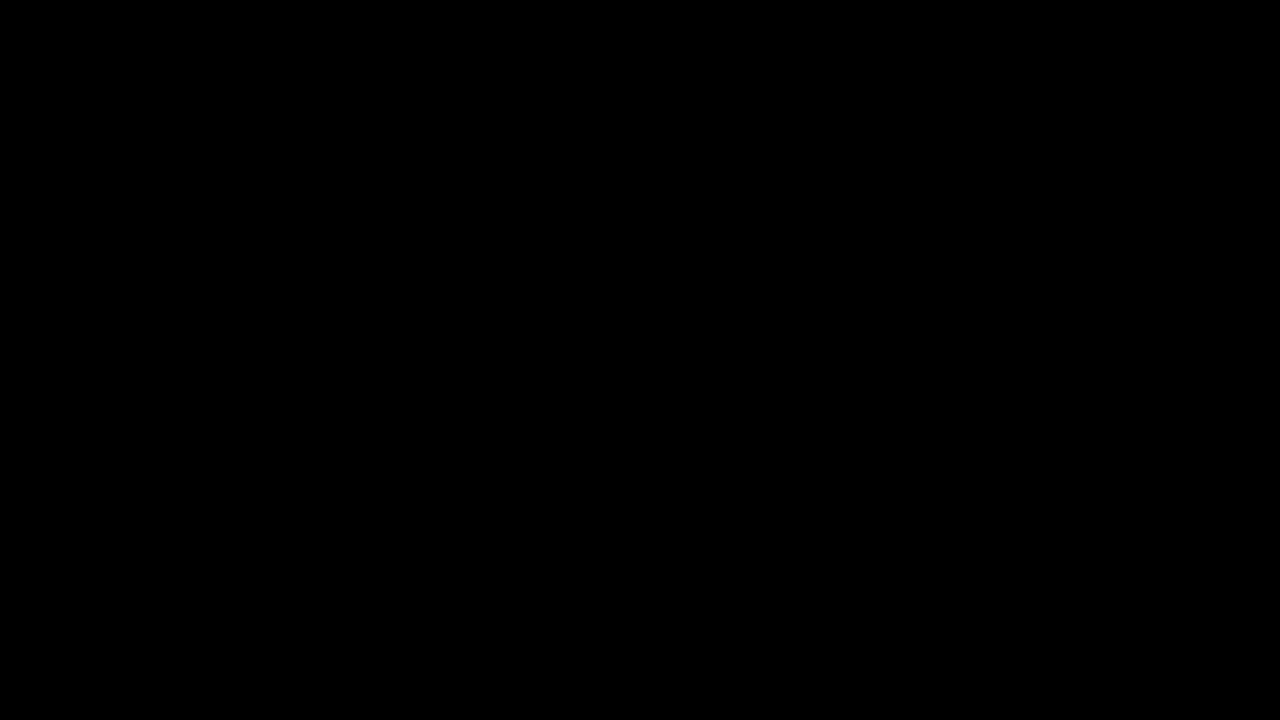

In [10]:
%%manim -qm -v WARNING ACFBuildUp


class ACFBuildUp(Scene):
    """Build up an ACF plot bar by bar, highlighting significant lags."""

    def construct(self):
        title = Text(
            "Autocorrelation Function (ACF) — AR(2) Process", font_size=26
        ).to_edge(UP)
        self.play(Write(title), run_time=0.5)

        # Generate AR(2) data: Y_t = 0.5 Y_{t-1} - 0.3 Y_{t-2} + eps
        n = 500
        np.random.seed(42)
        eps = np.random.normal(0, 1, n)
        y = np.zeros(n)
        for t in range(2, n):
            y[t] = 0.5 * y[t - 1] - 0.3 * y[t - 2] + eps[t]

        from statsmodels.tsa.stattools import acf as acf_func

        acf_vals = acf_func(y, nlags=15, fft=True)
        conf = 1.96 / np.sqrt(n)

        axes = Axes(
            x_range=[0, 16, 1],
            y_range=[-0.5, 1.1, 0.25],
            x_length=10,
            y_length=4.5,
            axis_config={"include_numbers": True, "font_size": 14},
        ).shift(DOWN * 0.3)
        x_lbl = axes.get_x_axis_label(
            Text("Lag h", font_size=16), edge=DOWN, direction=DOWN
        )
        y_lbl = axes.get_y_axis_label(
            Text("ρ(h)", font_size=16), edge=LEFT, direction=LEFT
        )
        self.play(Create(axes), Write(x_lbl), Write(y_lbl), run_time=0.6)

        # Confidence band
        conf_upper = DashedLine(
            axes.c2p(0, conf), axes.c2p(16, conf), color=GREY, stroke_width=1.5
        )
        conf_lower = DashedLine(
            axes.c2p(0, -conf), axes.c2p(16, -conf), color=GREY, stroke_width=1.5
        )
        self.play(Create(conf_upper), Create(conf_lower), run_time=0.4)

        # Build bars one by one
        for h in range(16):
            val = acf_vals[h]
            is_sig = abs(val) > conf
            color = C.SALMON if is_sig else C.PERIWINKLE

            bar_height = val * (4.5 / 1.6)
            bar = Line(axes.c2p(h, 0), axes.c2p(h, val), stroke_width=6, color=color)
            dot = Dot(axes.c2p(h, val), radius=0.06, color=color)

            speed = 0.3 if h < 5 else 0.12
            self.play(Create(bar), FadeIn(dot), run_time=speed)

        self.wait(1.5)

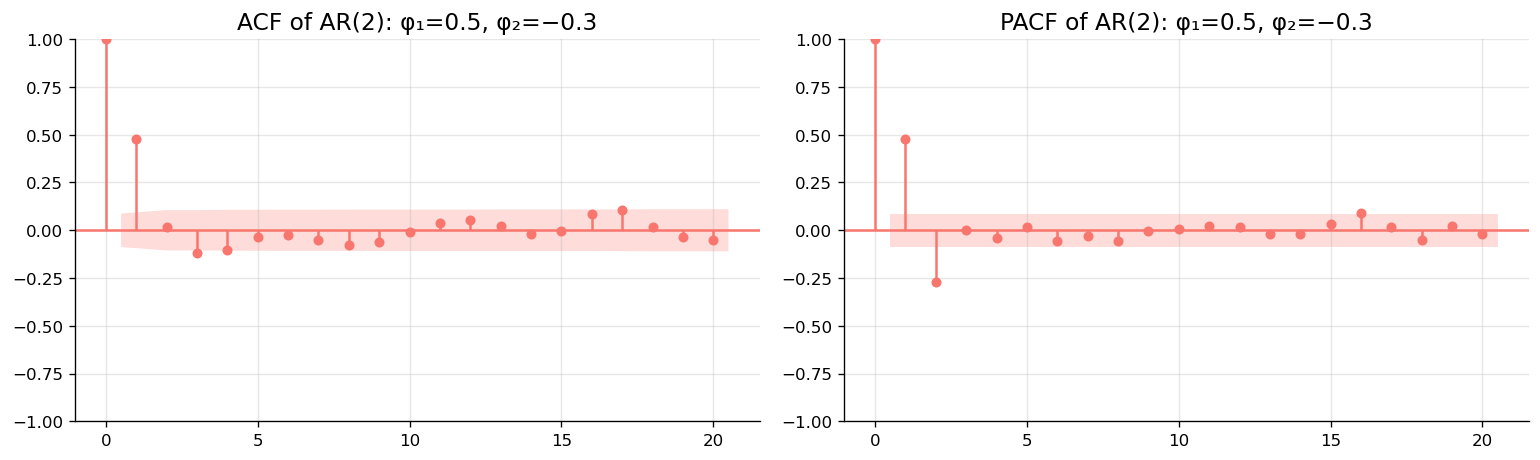

Notice: PACF cuts off sharply after lag 2 — the signature of an AR(2) process.
The ACF decays gradually because the indirect correlations persist through the chain.


In [11]:
# ACF and PACF for the AR(2) process using statsmodels
ar2 = np.zeros(500)
eps_ar2 = rng.normal(0, 1, 500)
for t in range(2, 500):
    ar2[t] = 0.5 * ar2[t - 1] - 0.3 * ar2[t - 2] + eps_ar2[t]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ar2, lags=20, ax=ax1, title="ACF of AR(2): φ₁=0.5, φ₂=−0.3")
plot_pacf(ar2, lags=20, ax=ax2, title="PACF of AR(2): φ₁=0.5, φ₂=−0.3", method="ywm")
plt.tight_layout()
plt.show()

print("Notice: PACF cuts off sharply after lag 2 — the signature of an AR(2) process.")
print(
    "The ACF decays gradually because the indirect correlations persist through the chain."
)

---

## 4. Autoregressive (AR) Models

### 4.1 Definition

An **autoregressive model of order $p$**, denoted AR($p$), expresses each observation as a linear combination of its $p$ most recent values plus noise:

$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \cdots + \phi_p Y_{t-p} + \varepsilon_t$$

where $\varepsilon_t \sim N(0, \sigma^2)$ is white noise and $\phi_1, \ldots, \phi_p$ are the AR coefficients.

**Connection to regression (Module 06):** This is literally a regression of $Y_t$ on its own lagged values! The "auto" in autoregressive means "self-regressing." The design matrix has columns $Y_{t-1}, Y_{t-2}, \ldots, Y_{t-p}$, and we estimate the $\phi$ coefficients by least squares or MLE.

### 4.2 Stationarity conditions

An AR($p$) process is stationary if and only if all roots of the **characteristic polynomial**

$$1 - \phi_1 z - \phi_2 z^2 - \cdots - \phi_p z^p = 0$$

lie **outside the unit circle** in the complex plane ($|z| > 1$).

For AR(1), this simplifies to $|\phi_1| < 1$. When $\phi_1 = 1$, we get a random walk (non-stationary). When $|\phi_1| > 1$, the process explodes.

### 4.3 ACF/PACF signature of AR models

This is the key diagnostic tool for identifying AR models from data:

| Model   | ACF                                        | PACF                   |
|---------|--------------------------------------------|------------------------|
| AR($p$) | Decays gradually (exponential/oscillating) | Cuts off after lag $p$ |

The PACF cutoff makes intuitive sense: in an AR($p$) model, $Y_t$ depends *directly* on $Y_{t-1}, \ldots, Y_{t-p}$ only. The PACF, which measures direct effects, should therefore be zero beyond lag $p$.

### 4.4 The effect of $\phi$: memory and persistence

The animation below shows how the AR(1) coefficient $\phi$ controls the "memory" of the process. With $\phi$ close to zero, each observation is nearly independent; with $\phi$ close to 1, the process moves slowly and has long-range correlation.

Manim Community v0.18.1

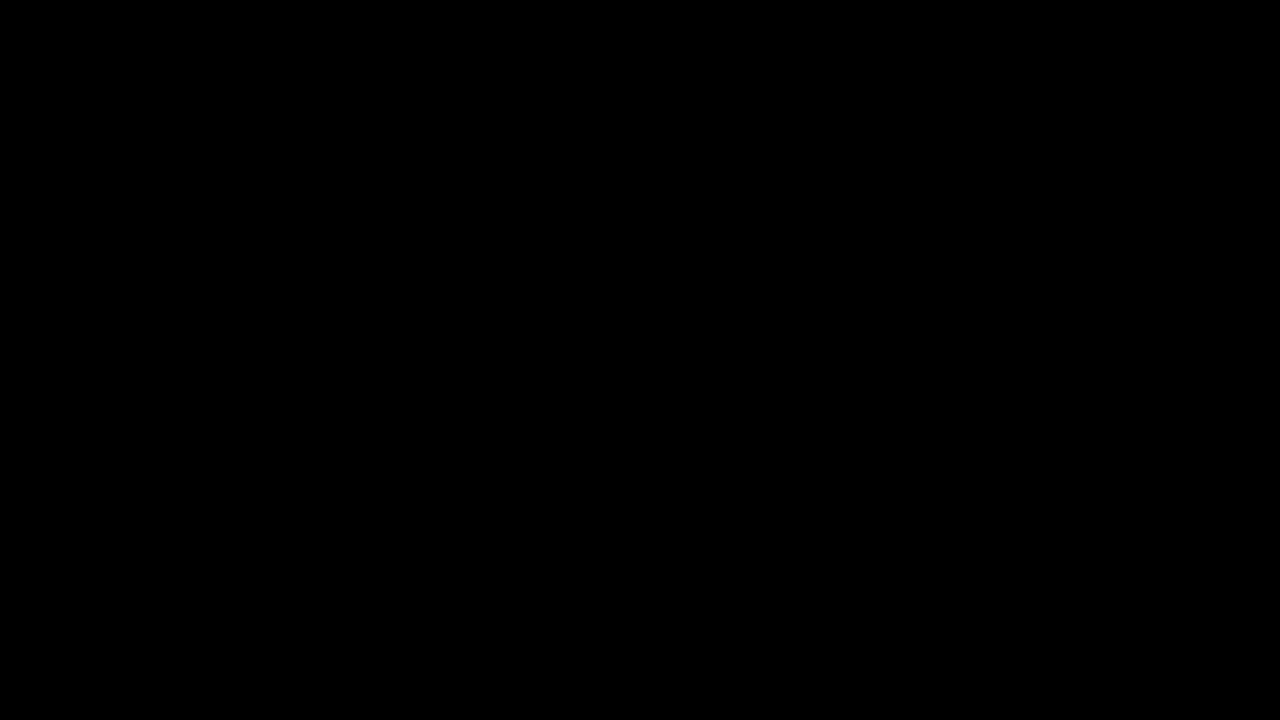

In [12]:
%%manim -qm -v WARNING ARPhiEffect


class ARPhiEffect(Scene):
    """Show AR(1) realisations for different phi values."""

    def construct(self):
        title = Text("AR(1): How φ Controls Memory", font_size=28).to_edge(UP)
        self.play(Write(title), run_time=0.5)

        phi_values = [0.2, 0.8, 0.95]
        colors = [C.EMERALD, C.GOLD, C.SALMON]
        n = 150

        axes = Axes(
            x_range=[0, n, 25],
            y_range=[-6, 6, 2],
            x_length=10,
            y_length=5,
            axis_config={"include_numbers": True, "font_size": 14},
        ).shift(DOWN * 0.3)
        x_lbl = axes.get_x_axis_label(
            Text("Time", font_size=16), edge=DOWN, direction=DOWN
        )
        self.play(Create(axes), Write(x_lbl), run_time=0.5)

        np.random.seed(42)
        eps = np.random.normal(0, 1, n)

        legend_items = VGroup()

        for phi, col in zip(phi_values, colors):
            y = np.zeros(n)
            for t in range(1, n):
                y[t] = phi * y[t - 1] + eps[t]

            points = [axes.c2p(t, y[t]) for t in range(n)]
            line = VMobject(color=col, stroke_width=2)
            line.set_points_smoothly(points)

            label = Text(f"φ = {phi}", font_size=18, color=col)
            legend_items.add(label)

            self.play(Create(line), run_time=1.2)

        legend_items.arrange(DOWN, aligned_edge=LEFT, buff=0.2).to_corner(UR).shift(
            DOWN * 0.5
        )
        for item in legend_items:
            self.play(Write(item), run_time=0.2)

        self.wait(1.5)

### 4.5 Fitting AR models with statsmodels

Let's simulate an AR(2) process with known parameters and see how well we can recover them.

In [13]:
# Simulate and fit AR(2): Y_t = 2 + 0.5*Y_{t-1} - 0.3*Y_{t-2} + eps
n = 1000
true_c, true_phi1, true_phi2, true_sigma = 2.0, 0.5, -0.3, 1.0

eps = rng.normal(0, true_sigma, n)
y = np.zeros(n)
y[0], y[1] = true_c, true_c
for t in range(2, n):
    y[t] = true_c + true_phi1 * y[t - 1] + true_phi2 * y[t - 2] + eps[t]

# Fit using statsmodels ARIMA(p=2, d=0, q=0) = AR(2)
model = ARIMA(y, order=(2, 0, 0))
result = model.fit()
print(result.summary().tables[1])
print(
    f"\nTrue parameters:     c={true_c}, φ₁={true_phi1}, φ₂={true_phi2}, σ={true_sigma}"
)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4084      0.038     62.789      0.000       2.333       2.484
ar.L1          0.4594      0.031     14.615      0.000       0.398       0.521
ar.L2         -0.2929      0.031     -9.444      0.000      -0.354      -0.232
sigma2         1.0197      0.045     22.652      0.000       0.931       1.108

True parameters:     c=2.0, φ₁=0.5, φ₂=-0.3, σ=1.0


---

## 5. Moving Average (MA) Models

### 5.1 Definition

A **moving average model of order $q$**, denoted MA($q$), expresses each observation as a linear combination of the current and past $q$ noise terms:

$$Y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q}$$

where $\varepsilon_t \sim N(0, \sigma^2)$ is white noise. Unlike AR models, which regress on past *values*, MA models depend on past *shocks*.

**Intuition:** An MA($q$) process has a **finite memory** of exactly $q$ periods. After a shock $\varepsilon_t$ occurs, it affects $Y_t, Y_{t+1}, \ldots, Y_{t+q}$ and then vanishes completely.

### 5.2 ACF/PACF signature of MA models

| Model   | ACF                        | PACF             |
|---------|----------------------------|------------------|
| MA($q$) | **Cuts off after lag $q$** | Decays gradually |

This is the mirror image of the AR pattern. The ACF cutoff makes sense: after $q$ lags, the shared $\varepsilon$ terms have no overlap.

### 5.3 Invertibility

Just as AR models need stationarity (roots outside unit circle), MA models need **invertibility**: the roots of $1 + \theta_1 z + \cdots + \theta_q z^q = 0$ must lie outside the unit circle. This ensures a unique representation and well-behaved estimation.

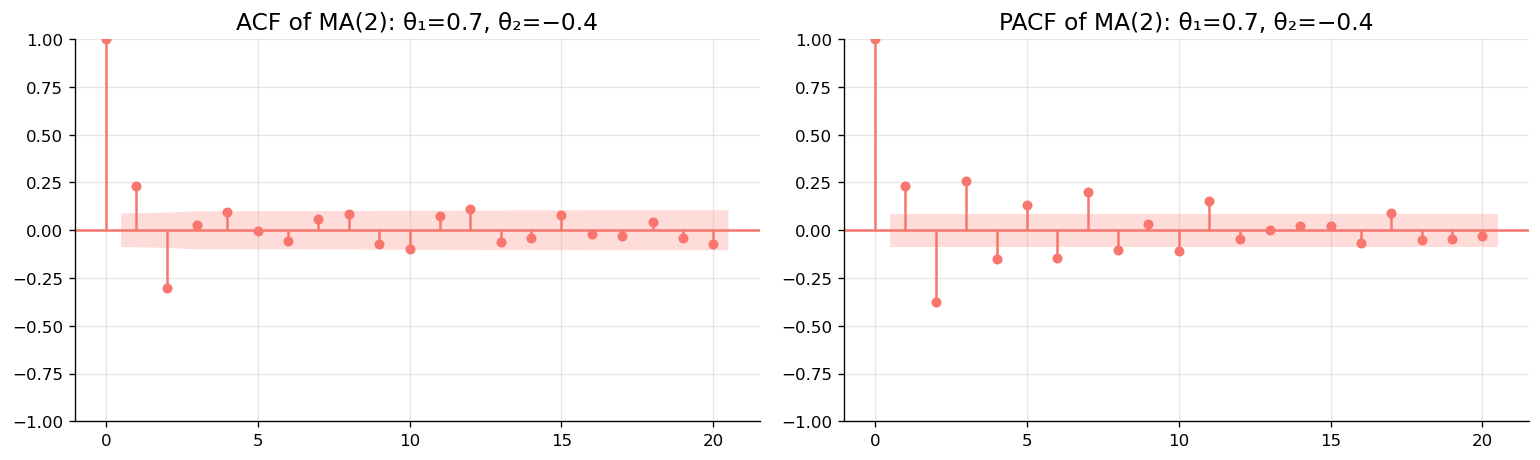

Notice: ACF cuts off after lag 2 — the signature of an MA(2) process.
The PACF decays gradually — the mirror image of what we saw for AR(2).


In [14]:
# Simulate MA(2) and check ACF/PACF signature
theta1, theta2 = 0.7, -0.4
eps_ma = rng.normal(0, 1, 500)
ma2 = np.zeros(500)
for t in range(2, 500):
    ma2[t] = eps_ma[t] + theta1 * eps_ma[t - 1] + theta2 * eps_ma[t - 2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ma2, lags=20, ax=ax1, title="ACF of MA(2): θ₁=0.7, θ₂=−0.4")
plot_pacf(ma2, lags=20, ax=ax2, title="PACF of MA(2): θ₁=0.7, θ₂=−0.4", method="ywm")
plt.tight_layout()
plt.show()

print("Notice: ACF cuts off after lag 2 — the signature of an MA(2) process.")
print("The PACF decays gradually — the mirror image of what we saw for AR(2).")

---

## 6. ARIMA Models

### 6.1 From ARMA to ARIMA

An **ARMA($p, q$)** model combines both AR and MA components:

$$Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}$$

This handles stationary data. For non-stationary data, we first difference $d$ times and then fit an ARMA to the differenced series. This is the **ARIMA($p, d, q$)** model:

- $p$ = order of the AR component (number of lagged values)
- $d$ = degree of differencing (number of times we subtract $Y_{t-1}$ from $Y_t$)
- $q$ = order of the MA component (number of lagged noise terms)

### 6.2 The Box-Jenkins methodology

George Box and Gwilym Jenkins (1970) established the standard workflow for ARIMA modelling:

**Step 1 — Identify:**
- Plot the series. Is there a trend? → differencing needed ($d \geq 1$)
- Apply ADF test. Still non-stationary after differencing? → increase $d$
- Examine ACF and PACF of the (differenced) series:
  - PACF cuts off at lag $p$ → AR($p$) component
  - ACF cuts off at lag $q$ → MA($q$) component
  - Both decay gradually → mixed ARMA, use information criteria

**Step 2 — Estimate:**
- Fit the ARIMA($p, d, q$) model via MLE. `statsmodels.tsa.arima.model.ARIMA` does this.
- Compare candidate models using **AIC** (Akaike Information Criterion) or **BIC** (Bayesian Information Criterion) — these penalise model complexity, exactly as we discussed in Module 06.05.

**Step 3 — Diagnose:**
- Check residuals: they should look like white noise
  - ACF of residuals should show no significant lags
  - **Ljung-Box test**: $H_0$: residuals are white noise
- If residuals show structure, revise the model (increase $p$, $q$, or $d$)

### 6.3 Worked example: the full Box-Jenkins pipeline

Let's generate a synthetic ARIMA(1,1,1) process and walk through the entire identification → estimation → diagnostics pipeline.

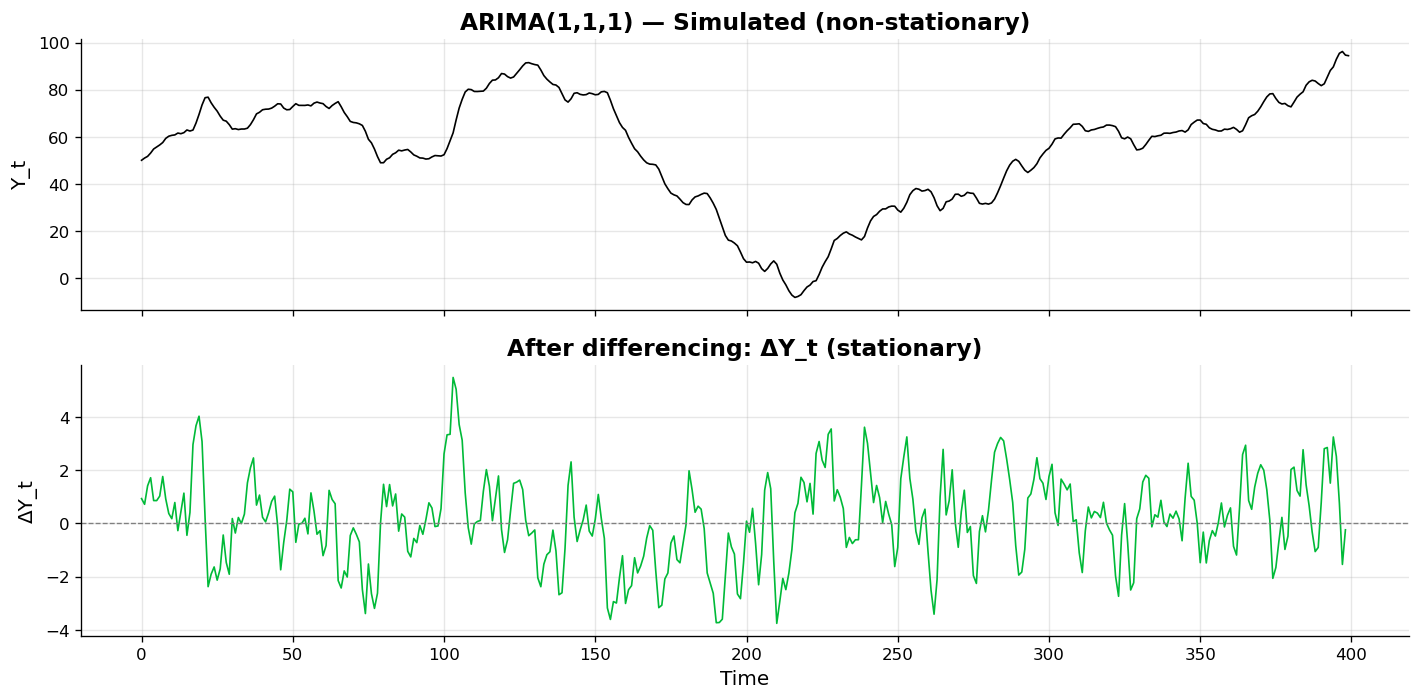

ADF on original series: p = 0.7133 → Non-stationary
ADF on differenced:     p = 0.000000 → Stationary

→ d = 1 differencing is sufficient.


In [16]:
# Generate ARIMA(1,1,1) data
# First create stationary ARMA(1,1), then integrate (cumsum) to make it non-stationary
n = 400
true_phi, true_theta = 0.6, 0.4
eps_arima = rng.normal(0, 1, n)

# ARMA(1,1) for the differenced series
z = np.zeros(n)
for t in range(1, n):
    z[t] = true_phi * z[t - 1] + eps_arima[t] + true_theta * eps_arima[t - 1]

# Integrate to get ARIMA(1,1,1)
y_arima = np.cumsum(z) + 50  # add offset for realism

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(y_arima, lw=1, color="black")
ax1.set_title("ARIMA(1,1,1) — Simulated (non-stationary)", fontweight="bold")
ax1.set_ylabel("Y_t")

y_diff = np.diff(y_arima)
ax2.plot(y_diff, lw=1, color=str(C.EMERALD))
ax2.axhline(0, color="gray", ls="--", lw=0.8)
ax2.set_title("After differencing: ΔY_t (stationary)", fontweight="bold")
ax2.set_ylabel("ΔY_t")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

# ADF test on original and differenced
adf_orig = adfuller(y_arima, autolag="AIC")
adf_diff = adfuller(y_diff, autolag="AIC")
print(
    f"ADF on original series: p = {adf_orig[1]:.4f} → {'Stationary' if adf_orig[1] < 0.05 else 'Non-stationary'}"
)
print(
    f"ADF on differenced:     p = {adf_diff[1]:.6f} → {'Stationary' if adf_diff[1] < 0.05 else 'Non-stationary'}"
)
print("\n→ d = 1 differencing is sufficient.")

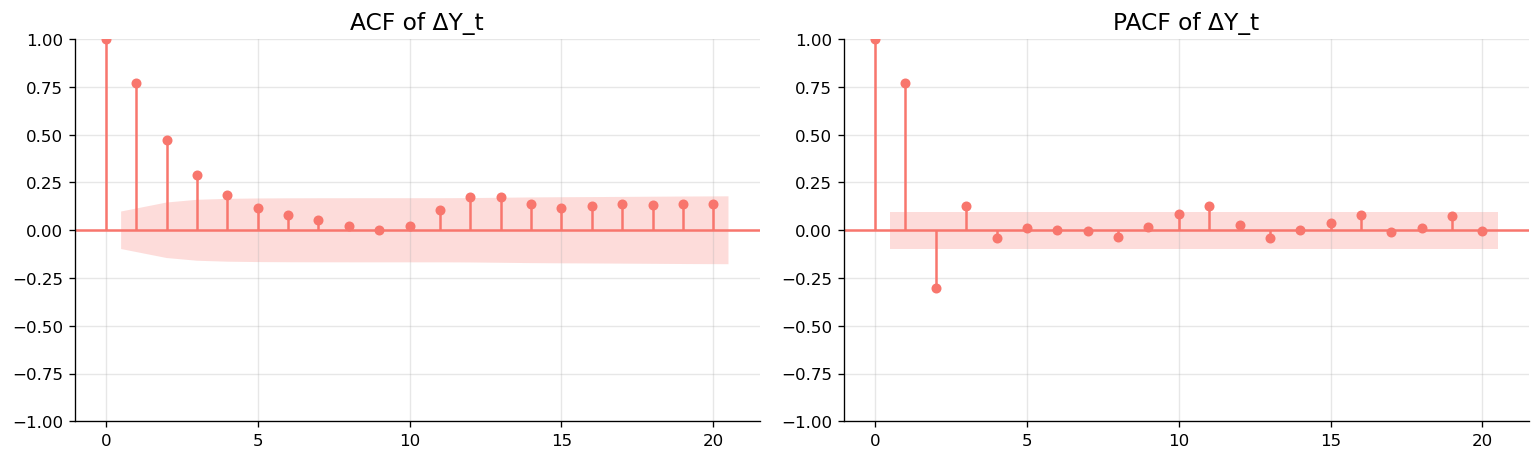

Both ACF and PACF decay gradually → suggests a mixed ARMA model.
We'll compare ARIMA(1,1,0), ARIMA(0,1,1), and ARIMA(1,1,1) using AIC.


In [17]:
# Step 1: Identify p and q from ACF/PACF of the differenced series
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(y_diff, lags=20, ax=ax1, title="ACF of ΔY_t")
plot_pacf(y_diff, lags=20, ax=ax2, title="PACF of ΔY_t", method="ywm")
plt.tight_layout()
plt.show()

print("Both ACF and PACF decay gradually → suggests a mixed ARMA model.")
print("We'll compare ARIMA(1,1,0), ARIMA(0,1,1), and ARIMA(1,1,1) using AIC.")

In [18]:
# Step 2: Estimate — compare candidate models via AIC
candidates = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1), (1, 1, 2)]

print(f"{'Model':<20s} {'AIC':>10s} {'BIC':>10s}")
print("-" * 42)
best_aic, best_order = np.inf, None
for order in candidates:
    try:
        m = ARIMA(y_arima, order=order).fit()
        aic, bic = m.aic, m.bic
        marker = ""
        if aic < best_aic:
            best_aic = aic
            best_order = order
            marker = " ← best"
        print(f"ARIMA{order!s:<14s} {aic:10.1f} {bic:10.1f}{marker}")
    except Exception as e:
        print(f"ARIMA{order!s:<14s} {'failed':>10s}")

print(f"\nSelected: ARIMA{best_order}")

Model                       AIC        BIC
------------------------------------------
ARIMA(1, 1, 0)          1159.5     1167.5 ← best
ARIMA(0, 1, 1)          1225.8     1233.8
ARIMA(1, 1, 1)          1116.9     1128.9 ← best
ARIMA(2, 1, 1)          1118.9     1134.8
ARIMA(1, 1, 2)          1118.9     1134.8

Selected: ARIMA(1, 1, 1)


c:\Users\Alexander_Timmer\Miniconda3\envs\amstats\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [19]:
# Step 3: Diagnose — fit the best model and check residuals
best_model = ARIMA(y_arima, order=best_order).fit()
print(best_model.summary().tables[1])
print(f"\nTrue parameters: φ = {true_phi}, θ = {true_theta}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6187      0.050     12.401      0.000       0.521       0.716
ma.L1          0.4263      0.057      7.526      0.000       0.315       0.537
sigma2         0.9451      0.069     13.775      0.000       0.811       1.080

True parameters: φ = 0.6, θ = 0.4


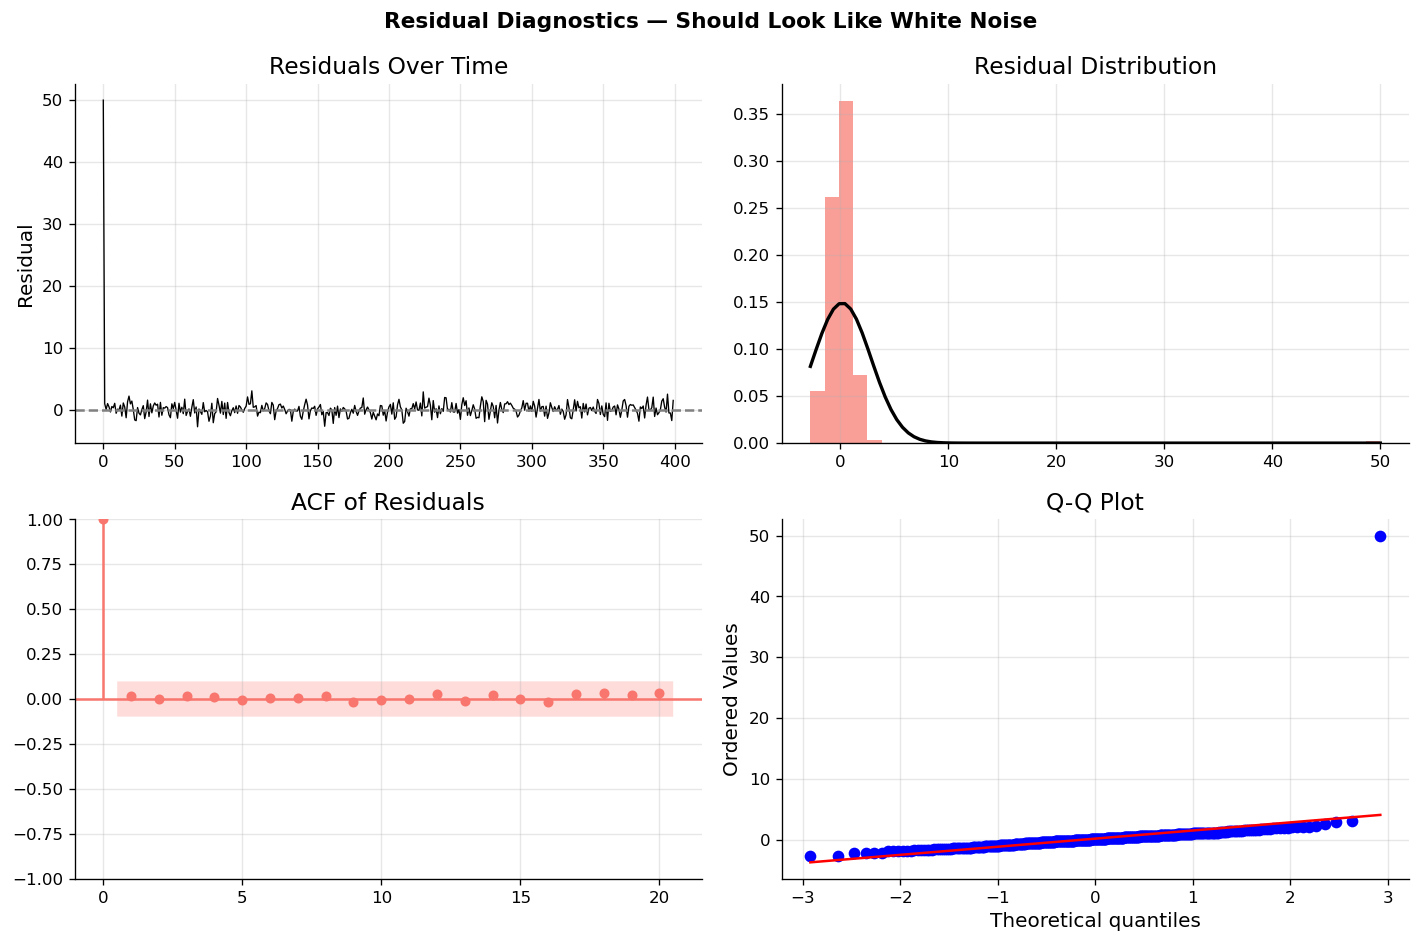

Ljung-Box test (H₀: residuals are white noise):
     lb_stat  lb_pvalue
10  0.546077   0.999990
20  2.779176   0.999998


In [20]:
# Residual diagnostics
resid = best_model.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time series of residuals
axes[0, 0].plot(resid, lw=0.8, color="black")
axes[0, 0].axhline(0, color="gray", ls="--")
axes[0, 0].set_title("Residuals Over Time")
axes[0, 0].set_ylabel("Residual")

# Histogram
axes[0, 1].hist(resid, bins=40, density=True, alpha=0.7)
x_norm = np.linspace(resid.min(), resid.max(), 100)
axes[0, 1].plot(x_norm, stats.norm(resid.mean(), resid.std()).pdf(x_norm), "k-", lw=2)
axes[0, 1].set_title("Residual Distribution")

# ACF of residuals
plot_acf(resid, lags=20, ax=axes[1, 0], title="ACF of Residuals")

# QQ plot
stats.probplot(resid, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

fig.suptitle(
    "Residual Diagnostics — Should Look Like White Noise",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print("Ljung-Box test (H₀: residuals are white noise):")
print(lb.to_string())

---

## 7. Forecasting and Evaluation

### 7.1 Producing forecasts

Once we have a fitted ARIMA model, we can forecast future values. The model produces:
- **Point forecasts**: the conditional expectation $\hat{Y}_{T+h} = E[Y_{T+h} \mid Y_1, \ldots, Y_T]$
- **Prediction intervals**: reflecting the uncertainty, which grows with the forecast horizon

### 7.2 Evaluation metrics

To assess forecast quality, we use:

$$\text{MAE} = \frac{1}{H} \sum_{h=1}^{H} |Y_{T+h} - \hat{Y}_{T+h}|$$

$$\text{RMSE} = \sqrt{\frac{1}{H} \sum_{h=1}^{H} (Y_{T+h} - \hat{Y}_{T+h})^2}$$

$$\text{MAPE} = \frac{100}{H} \sum_{h=1}^{H} \left|\frac{Y_{T+h} - \hat{Y}_{T+h}}{Y_{T+h}}\right|$$

### 7.3 Walk-forward validation

In cross-sectional data, we use $k$-fold cross-validation. For time series, we **cannot randomly split** the data because that would break the temporal order. Instead, we use **walk-forward validation**:

1. Train on $Y_1, \ldots, Y_t$
2. Forecast $\hat{Y}_{t+1}$
3. Expand the training set to include $Y_{t+1}$
4. Repeat

This respects the temporal structure and gives an honest estimate of out-of-sample performance.

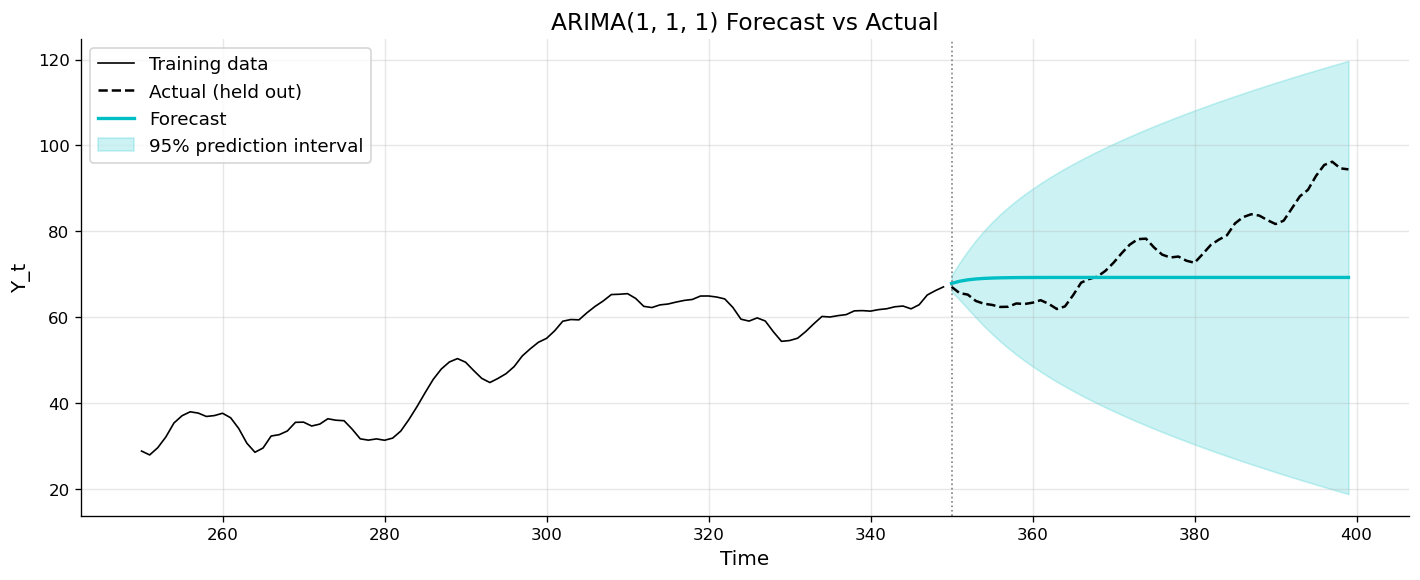

MAE  = 9.233
RMSE = 11.615


In [23]:
# Forecasting: train on first 350 points, forecast the last 50
train = y_arima[:350]
test = y_arima[350:]

model_fc = ARIMA(train, order=best_order).fit()
forecast = model_fc.get_forecast(steps=len(test))
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
t_train = np.arange(len(train))
t_test = np.arange(len(train), len(y_arima))

ax.plot(t_train[-100:], train[-100:], "k-", lw=1, label="Training data")
ax.plot(t_test, test, "k--", lw=1.5, label="Actual (held out)")
ax.plot(t_test, fc_mean, color=str(C.CYAN), lw=2, label="Forecast")
ax.fill_between(
    t_test,
    fc_ci[:, 0],
    fc_ci[:, 1],
    color=str(C.CYAN),
    alpha=0.2,
    label="95% prediction interval",
)
ax.axvline(len(train), color="gray", ls=":", lw=1)
ax.set_xlabel("Time")
ax.set_ylabel("Y_t")
ax.set_title(f"ARIMA{best_order} Forecast vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

# Compute metrics
mae = np.mean(np.abs(test - fc_mean))
rmse = np.sqrt(np.mean((test - fc_mean) ** 2))
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")

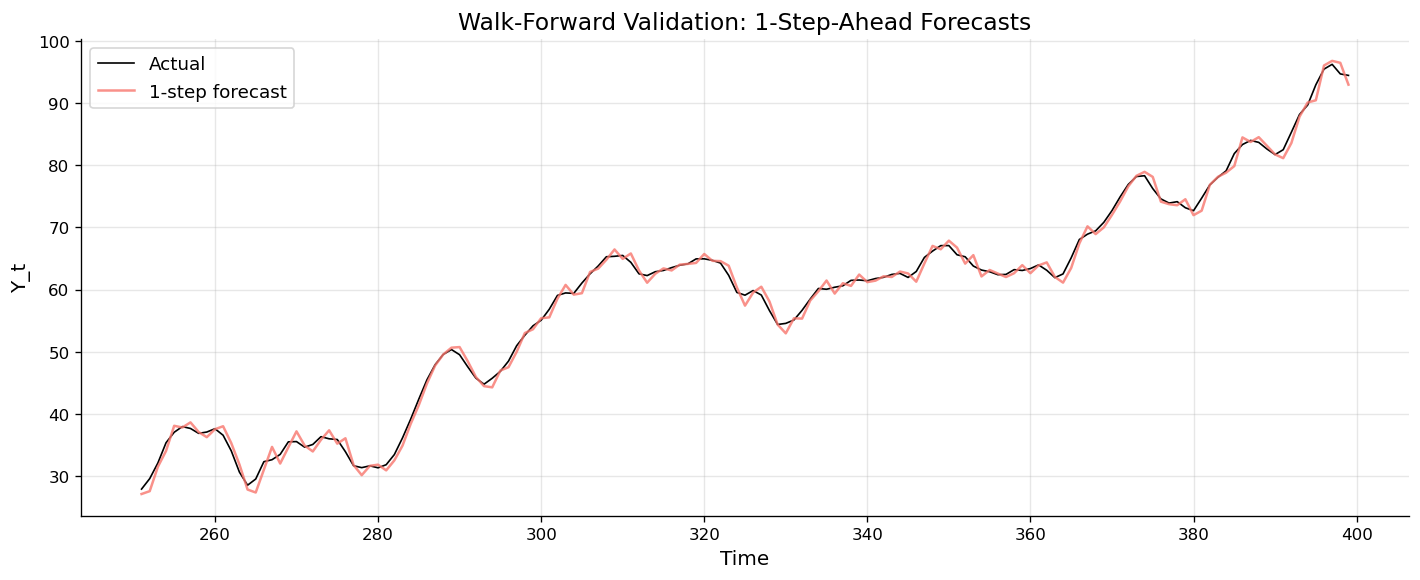

Walk-forward MAE  = 0.813
Walk-forward RMSE = 0.992


In [26]:
# Walk-forward validation
start_idx = 250
forecasts_wf = []
actuals_wf = []

for t in range(start_idx, len(y_arima) - 1):
    train_wf = y_arima[: t + 1]
    model_wf = ARIMA(train_wf, order=best_order).fit()
    fc = model_wf.forecast(steps=1)
    forecasts_wf.append(fc[0])
    actuals_wf.append(y_arima[t + 1])

forecasts_wf = np.array(forecasts_wf)
actuals_wf = np.array(actuals_wf)

fig, ax = plt.subplots(figsize=(12, 5))
t_wf = np.arange(start_idx + 1, len(y_arima))
ax.plot(t_wf, actuals_wf, "k-", lw=1, label="Actual")
ax.plot(
    t_wf, forecasts_wf, color=str(C.SALMON), lw=1.5, alpha=0.8, label="1-step forecast"
)
ax.set_xlabel("Time")
ax.set_ylabel("Y_t")
ax.set_title("Walk-Forward Validation: 1-Step-Ahead Forecasts")
ax.legend()
plt.tight_layout()
plt.show()

wf_mae = np.mean(np.abs(actuals_wf - forecasts_wf))
wf_rmse = np.sqrt(np.mean((actuals_wf - forecasts_wf) ** 2))
print(f"Walk-forward MAE  = {wf_mae:.3f}")
print(f"Walk-forward RMSE = {wf_rmse:.3f}")

---

## 8. Connections to the Broader Course

Time series methods connect deeply to topics you've already studied:

- **AR models are regression** (Module 06) with lagged values as predictors. The OLS estimator for AR coefficients is a special case of linear regression.
- **MLE** (Module 04.03) is how `statsmodels` fits ARIMA models. The log-likelihood of a Gaussian ARIMA model has a specific form involving the innovation variance.
- **Model selection via AIC/BIC** (Module 06.05) applies directly — we used it above to choose between candidate ARIMA orders.
- **Bayesian time series:** In Modules 07–08, you learned Bayesian regression. Bayesian structural time series models (BSTS) put priors on trend, seasonality, and regression coefficients. PyMC can fit these models directly.
- **State-space models** generalise ARIMA — they express the same models in a recursive form that naturally handles missing data, time-varying parameters, and multiple time series. This connects to hidden Markov models (a possible future Module 12 topic).

---

## Key Takeaways

1. **Time series data is fundamentally different** from cross-sectional data because observations are temporally dependent. This dependence is what makes modelling and forecasting possible.

2. **Stationarity** is the key assumption: constant mean, constant variance, and autocovariance that depends only on lag. Non-stationary data must be transformed (typically by differencing) before modelling.

3. **ACF and PACF** are the primary diagnostic tools. AR($p$) models have PACF that cuts off at lag $p$; MA($q$) models have ACF that cuts off at lag $q$.

4. **ARIMA($p, d, q$)** unifies differencing, autoregression, and moving averages into a flexible framework. The Box-Jenkins methodology (identify → estimate → diagnose) is the standard workflow.

5. **Forecasting** requires walk-forward validation — you cannot randomly split time series data. Prediction intervals grow with the forecast horizon because uncertainty compounds.

6. **Time series methods build on regression and MLE** from earlier modules. Bayesian extensions (structural time series, state-space models) connect to Module 07–08.

---

## Exercises

**Exercise 1.1 (Simulating and identifying).** Simulate 500 observations from each of the following processes. For each, plot the ACF and PACF and explain how you would identify the correct model order from the plots alone:
- (a) AR(1) with $\phi = 0.9$
- (b) MA(1) with $\theta = -0.5$
- (c) ARMA(1,1) with $\phi = 0.6, \theta = 0.3$

**Exercise 1.2 (Real data).** Download a real-world time series dataset (e.g., monthly airline passengers, daily stock prices, or weekly COVID cases). Apply the full Box-Jenkins pipeline: test for stationarity, difference if needed, examine ACF/PACF, fit candidate ARIMA models, select via AIC, and diagnose residuals.

**Exercise 1.3 (Forecast evaluation).** Using the airline passengers dataset (or your choice), split the data 80/20 into train/test. Fit ARIMA models of varying orders and compare their out-of-sample RMSE. Does more complex always mean better?

**Exercise 1.4 (Connection to regression).** Fit an AR(2) model to simulated data using (a) `statsmodels.tsa.arima.model.ARIMA` and (b) `statsmodels.OLS` with manually constructed lagged columns. Compare the coefficient estimates. Why are they not exactly the same? *(Hint: think about the likelihood vs OLS and the treatment of initial values.)*

In [27]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/ACFBuildUp@2026-03-21@22-29-38.gif
  ✓ media/gifs/ARPhiEffect@2026-03-21@22-30-22.gif
  ✓ media/gifs/ACFBuildUp_ManimCE_v0.18.1.gif
  ✓ media/gifs/ARPhiEffect_ManimCE_v0.18.1.gif
  Cleaned up local temp render files.


---

**Next:** [Module 13 — Digital Chemistry](../13_digital_chemistry/01_qsar_molecular_property_prediction.ipynb) — Applying statistical and machine learning methods to molecular data.